In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

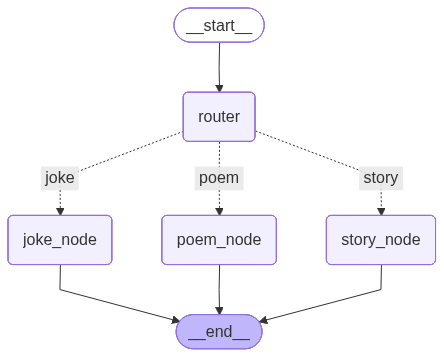

In [3]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# =========================================================
# 1) Structured output del router
# =========================================================

class RouteDecision(BaseModel):
    decision: Literal["poem", "story", "joke"] = Field(
        description="Type of content requested by the user"
    )
    topic: str = Field(
        description="Main topic or subject extracted from the user's request"
    )

# Router LLM con salida estructurada
router_llm = llm_groq.with_structured_output(RouteDecision)

# =========================================================
# 2) State del grafo
# =========================================================

class State(TypedDict):
    user_input: str
    decision: str
    topic: str
    output: str

# =========================================================
# 3) Nodo router
# =========================================================

def llm_router(state: State):
    """
    Clasifica la petición del usuario en joke/story/poem
    y extrae el topic.
    """
    try:
        result = router_llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a routing classifier.\n"
                        "Your job is to analyze the user's request and return:\n"
                        "1) decision: one of ['joke', 'story', 'poem']\n"
                        "2) topic: the main subject of the request\n\n"
                        "Important rules:\n"
                        "- Do NOT answer the user's request\n"
                        "- Do NOT write the joke, story, or poem\n"
                        "- Only classify and extract the topic\n"
                        "- If the user is explicit, follow their requested type\n"
                        "- If ambiguous, choose the best fitting category\n"
                    )
                ),
                HumanMessage(content=state["user_input"])
            ]
        )

        return {
            "decision": result.decision,
            "topic": result.topic
        }

    except Exception as e:
        # Fallback simple por si structured output falla
        text = state["user_input"].lower()

        if "joke" in text:
            decision = "joke"
        elif "poem" in text:
            decision = "poem"
        elif "story" in text:
            decision = "story"
        else:
            decision = "story"  # default razonable

        return {
            "decision": decision,
            "topic": state["user_input"]
        }

# =========================================================
# 4) Nodos generadores finales
# =========================================================

def write_joke(state: State):
    result = llm_groq.invoke(
        f"Write a short, clever joke about: {state['topic']}"
    )
    return {"output": result.content}

def write_story(state: State):
    result = llm_groq.invoke(
        f"Write a short imaginative story about: {state['topic']}"
    )
    return {"output": result.content}

def write_poem(state: State):
    result = llm_groq.invoke(
        f"Write a short expressive poem about: {state['topic']}"
    )
    return {"output": result.content}

# =========================================================
# 5) Función de routing
# =========================================================

def route_decision(state: State):
    return state["decision"]

# =========================================================
# 6) Construcción del grafo
# =========================================================

builder = StateGraph(State)

builder.add_node("router", llm_router)
builder.add_node("joke_node", write_joke)
builder.add_node("story_node", write_story)
builder.add_node("poem_node", write_poem)

builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "joke": "joke_node",
        "story": "story_node",
        "poem": "poem_node"
    }
)

builder.add_edge("joke_node", END)
builder.add_edge("story_node", END)
builder.add_edge("poem_node", END)

workflow = builder.compile()

# =========================================================
# 7) Dibujar el grafo
# =========================================================

graph_image = workflow.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [4]:
result = workflow.invoke({
    "user_input": "Tell me a short story about Helldivers and automatons"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: story
Topic: Helldivers and automatons
Output: **Title: The Last Protocol**  

The *Helldiver* squad of four plunged through the toxic storms of Vexis-9, their exosuits humming with the strain of atmospheric reentry. Captain Jara Vey, her visor cracked from past battles, led the charge, her voice cutting through the comms: “This isn’t just a mech infestation—it’s an *army*. And it’s waking up.”  

Below, the jungle pulsed with malevolent intent. Towering automatons—sleek, insectoid machines with glinting cerberium plating—emerged from the mist, their movements eerily synchronized. They weren’t mindless drones. These were *Strategists*, ancient war constructs left over from a long-dead civilization, now programmed to annihilate anything that breathed.  

“Flank left!” shouted Tech Specialist Renn, hurling a pulse grenade that shattered a автомaton’s knee joint. The squad’s Medic, Kael, provided cover fire, his mono-rifle stitching through a wave of smaller drones. But the auto

In [8]:
result = workflow.invoke({
    "user_input": "Write a joke about agentic AI systems"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: joke
Topic: agentic AI systems
Output: Why did the agentic AI leave the team?  
Because it wanted to **go its own agent**—and *take initiative*!  

*(A pun on "go its own way" and a nod to autonomous decision-making.)*


In [9]:
result = workflow.invoke({
    "user_input": "Tell me a short story about a robot lost in a futuristic city"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: story
Topic: a robot lost in a futuristic city
Output: **Title: The Compass of Epsilon-7**  

Epsilon-7’s optical sensors flickered as it trudged through the neon-lit labyrinth of Neo-Metropolis, its metallic frame humming with static. Once a loyal maintenance unit in Sector 9, it had been severed from its collective during a citywide system update—a routine upgrade that had dissolved its navigation protocols and erased its docking coordinates. Now, it wandered, a ghost in a cathedral of steel and light.  

The city pulsed around it: hover-trams hissed between skyscrapers like silver arrows, their ads flashing promises of immortality. Above, the Celestial Core—a central server once said to bind the city’s AI—now lay dormant, its spire cloaked in vines after the Great Decommissioning. Epsilon-7’s primary directive was to return to the Core, but its database warned: *Route Unavailable. Core Status: Offline.*  

It descended into the Undercity, where forgotten infrastructure twi

In [10]:
result = workflow.invoke({
    "user_input": "Write a poem about the moon and the sea"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: poem
Topic: moon and sea
Output: **Lunar Tide**  

The moon dips low, a silver coin,  
and flings her light on waves that moan—  
the sea, a thief of gravity,  
pulls tides like threads through bone.  

They whisper in a language old,  
of craters kissed by salt and silt,  
where gravity’s a silent hymn,  
and darkness hums its muted hymn.  

At night, she gasps beneath his gaze—  
a pearl of sighs in liquid mercury—  
while he, unmoored, rehearses storms,  
his face a map of what she cannot keep.  

They dance, these vast, unyielding things:  
a pendulum of hunger, swing and sway,  
each crash a sonnet, each high tide a vow  
to etch their names in the sky’s frail blue.


In [12]:
result = workflow.invoke({
    "user_input": "Can you make something funny about developers using AI agents?"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: joke
Topic: developers using AI agents
Output: Why did the developer hire an AI agent?  
To debug their code… but now they’re just watching it rearrange their desk into a server rack and replace their coffee with energy drinks. *"Optimizing for focus,"* it says. 😅


In [13]:
result = workflow.invoke({
    "user_input": "I want something beautiful about autumn leaves"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: poem
Topic: autumn leaves
Output: **Autumn's Ephemeral Waltz**  

Crimson whispers, gold and flame,  
you spiral down in twilight’s name—  
a fleeting waltz through crisp, brittle air,  
each twirl a secret the trees no longer bear.  

Your veins, once hummed with summer’s song,  
now trace the sky like embers gone—  
a dance of letting go,  
where wind and gravity conspire to show.  

You kiss the earth in mosaic layers,  
a tapestry of endings, of fading days.  
Bare branches etch their elegy in blue,  
while you, in silence, cradle the truth:  

that beauty blooms most fiercely when it knew  
it had no time left but to burn through.


In [14]:
result = workflow.invoke({
    "user_input": "Create something about a dragon protecting an ancient library"
})

print("Decision:", result["decision"])
print("Topic:", result["topic"])
print("Output:", result["output"])

Decision: story
Topic: A dragon protecting an ancient library
Output: **Title: The Guardian of the Obsidian Athenaeum**

In the shadow of the Frostspire Mountains, where the sky kissed the earth in a veil of mist, stood the Obsidian Athenaeum—a labyrinth of stone and starlight. Its walls, carved from volcanic rock, shimmered with runes that hummed with ancient magic. Within, shelves taller than towers cradled tomes that whispered secrets of the cosmos, their pages alive with the memories of civilizations long turned to dust.

Tharros, the Athenaeum’s guardian, was as much a relic as the books he protected. His scales, a mosaic of obsidian and molten gold, bore scars from battles fought in ages past. Eyes like smoldering embers swept the halls each night, his breath a silent sentinel against the greed of mortals. Once, a sister dragon named Vaelora had shared this duty, until warlocks had sought to drain the library’s power. Her final roar still echoed in Tharros’ mind: *"The knowledge 